In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Capse_Planck`


In [2]:
# Pkg.add("Random")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("PosteriorStats")
# Pkg.add("Distributions")
# Pkg.add("PDMats")
# Pkg.add("LogExpFunctions")
# Pkg.add("Plots")
# Pkg.add("ArviZ")
# Pkg.add("HypothesisTests)

In [3]:
using Random
using LinearAlgebra
using Turing
using PosteriorStats
using Distributions
using PDMats
using LogExpFunctions
using Plots
using ArviZ

[ Info: Precompiling Turing [fce5fe82-541a-59a6-adf8-730c64b5f9a0] (cache misses: wrong dep version loaded (6), dep missing source (8))
[ Info: Precompiling PosteriorStats [7f36be82-ad55-44ba-a5c0-b8b5480d7aa5] (cache misses: wrong dep version loaded (14))
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] (cache misses: wrong dep version loaded (12))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (4))
[ Info: Precompiling ArviZ [131c737c-5715-5e2e-ad31-c244f01c1dc7] (cache misses: wrong dep version loaded (14))
[ Info: Precompiling ArviZMCMCChainsExt [034f4187-2400-5fc4-9f10-ee6086205b7b] (cache misses: wrong dep version loaded (14))


### Set up the linear model, perform a random draw of synthetic "observed" data, and run the chain to generate the posterior distributions that predictions are made from

In [4]:
# Define the Turing model
@model function myfoo(SL, x)
    a ~ Uniform(-10, 10)
    b ~ Uniform(-10, 10)
    μ = a .* x .+ b
    S = Symmetric(SL * SL')
    # Multivariate Normal observation
    y ~ MvNormal(μ, PDMat(Cholesky(SL)))
    return y
end

# Setup synthetic data
Random.seed!(1234)
n = 30
R = rand(LKJCholesky(n, 1))
s = rand(filldist(truncated(TDist(7); lower=0), n))
SL = LowerTriangular(Diagonal(s) * R.L) + 0.2I
S = Symmetric(SL * SL')

x = Array(LinRange(-7, 7, n))
a_true = 1.0
b_true = -3.0
y = rand(MvNormal(a_true .* x .+ b_true, S))

30-element Vector{Float64}:
  -9.811564924143633
 -10.859840383966228
  -9.091690033414517
  -8.570246921218109
 -10.586146979442375
  -5.128049478783716
  -7.196124048463768
  -6.974107919160579
  -6.073239474725736
  -5.920146893325242
  -4.3899527348900005
  -4.781161200590691
  -2.3293350537935207
   ⋮
   0.5989245684782158
  -0.2821605760613628
  -1.2792819817595082
   2.1628259832751353
   1.1221721985676112
   1.5957980129853748
   2.0078461434577406
   2.8730649182169663
   6.314391068164985
   3.298919808147355
   5.243683187706106
   3.90450160041801

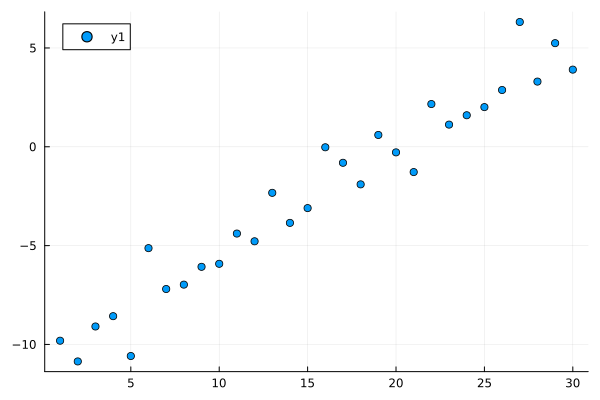

In [5]:
scatter(y)

In [6]:
# Sample from the model using 8 parallel chains
chns = sample(myfoo(SL, x) | (; y), NUTS(), MCMCThreads(), 2000, 8)

# Generate posterior predictions: stochastic realizations from the likelihood
y_pred = predict(myfoo(SL, x), chns)

┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.003125
┌ Info: Found initial step size
└   ϵ = 0.00625
Sampling (4 threads):  38%|███████████▏                 |  ETA: 0:00:02┌ Info: Found initial step size
└   ϵ = 0.0125
┌ Info: Found initial step size
└   ϵ = 0.00625
┌ Info: Found initial step size
└   ϵ = 0.00625
Sampling (4 threads):  50%|██████████████▍              |  ETA: 0:00:05┌ Info: Found initial step size
└   ϵ = 0.00625
Sampling (4 threads): 100%|█████████████████████████████| Time: 0:00:05


Chains MCMC chain (2000×30×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Float64      Float64      Float64   Float6 ⋯

        y[1]   -10.1154    1.0680    0.0084   16052.1143   15619.2564    1.000 ⋯
        y[2]    -9.6302    0.9799    0.0079   15316.4400   15281.4769    1.000 ⋯
        y[3]    -9.1219    3.2593    0.0257   16042.2965   15360.2082    1.000 ⋯
        y[4]    -8.6605    1.8395    0.0144   16221.2487   15340.1434    0.999 ⋯
        y[5]    -8.1408    1.1395    0.0091   15751.9522   15859.8987    1.000 ⋯
        y[6]    -7.6571    1.1184    0.0088  

### Marco's Manual LOO-PIT

In [7]:
# Extract parameter samples
a_samples = chns[:a].data
b_samples = chns[:b].data

# Compute the mean array for all draws and chains (draws, chains, n)
μ_array = a_samples .* reshape(x, 1, 1, n) .+ b_samples
S_pd = PDMat(Cholesky(SL))

# Instantiate distributions for each posterior slice
dists = map(μ -> MvNormal(μ, S_pd), eachslice(μ_array; dims=(1, 2)))

# Calculate pointwise conditional log-likelihoods
log_like = PosteriorStats.pointwise_conditional_loglikelihoods(y, dists)

2000×8×30 Array{Float64, 3}:
[:, :, 1] =
 -0.892823  -0.375793  -1.50165   …  -0.812887  -1.84338    -0.109619
 -2.18487   -0.392198  -1.09913      -2.00517   -0.336721   -2.06813
 -2.73159   -0.616539  -2.03185      -1.05128   -1.89675    -0.216221
 -1.81355   -0.586787  -2.73763      -1.05128   -1.7057     -0.961709
 -2.60961   -0.649942  -0.800654     -0.389567  -0.0238539  -1.01569
 -0.650271  -0.762879  -0.800654  …  -0.389567  -1.64238    -0.521548
 -1.48196   -0.611852  -0.786145     -1.23944   -0.441323   -0.430765
 -1.01602   -1.34901   -1.4348       -1.13091   -2.45273    -0.903171
 -0.655844  -1.35346   -1.57393      -1.60943   -3.77489    -0.839258
 -0.683102  -1.00947   -0.374642     -1.57516   -4.58411    -0.407184
 -0.288229  -0.648893  -1.02057   …  -1.15573   -1.63317    -0.554463
 -0.434668  -0.450736  -0.633819     -1.88132   -1.29261    -1.03574
 -0.434668  -0.931471  -0.392679     -0.717991  -1.8849     -0.914908
  ⋮                               ⋱   ⋮             

In [8]:
# Compute LOO to obtain smoothed importance weights
loo_res = loo(log_like)
log_weights = loo_res.psis_result.log_weights

2000×8×30 Array{Float64, 3}:
[:, :, 1] =
 -10.2771   -10.7941    -9.66824  …  -10.357     -9.32651  -11.0603
  -8.98502  -10.7777   -10.0708       -9.16472  -10.8332    -9.10175
  -8.43829  -10.5533    -9.13803     -10.1186    -9.27313  -10.9537
  -9.35634  -10.5831    -8.43226     -10.1186    -9.46419  -10.2082
  -8.56028  -10.5199   -10.3692      -10.7803   -11.146    -10.1542
 -10.5196   -10.407    -10.3692   …  -10.7803    -9.5275   -10.6483
  -9.68793  -10.558    -10.3837       -9.93044  -10.7286   -10.7391
 -10.1539    -9.82087   -9.73508     -10.039     -8.71716  -10.2667
 -10.514     -9.81642   -9.59596      -9.56046   -7.4304   -10.3306
 -10.4868   -10.1604   -10.7952       -9.59473   -6.56296  -10.7627
 -10.8817   -10.521    -10.1493   …  -10.0142    -9.53671  -10.6154
 -10.7352   -10.7191   -10.5361       -9.28856   -9.87727  -10.1341
 -10.7352   -10.2384   -10.7772      -10.4519    -9.28499  -10.255
   ⋮                              ⋱    ⋮                   
 -10.7865    -9

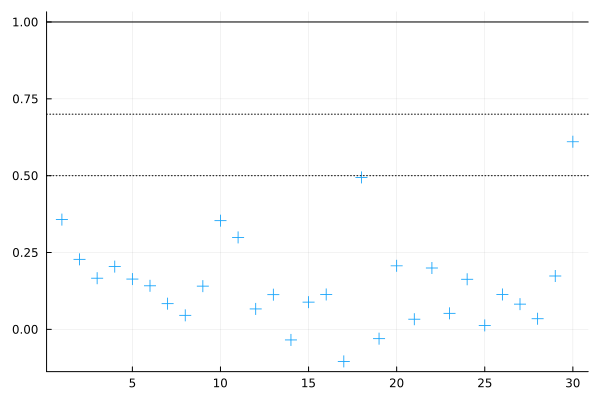

In [9]:
scatter(loo_res.pointwise.pareto_shape; marker=:+, markersize = 6, legend=false, linewidth=2)
hline!([0.5, 0.7], linestyle=:dot, color=:black)
hline!([1.0], linestyle=:solid, color=:black)

In [10]:
# Clean predictions into (draws, chains, n)
y_pred_array = permutedims(y_pred[[Symbol("y[$i]") for i in 1:n]].value.data, (1, 3, 2))

pitvals_manual = zeros(n)
for i in 1:n
    y_pred_i = y_pred_array[:, :, i] 
    log_w_i = log_weights[:, :, i]
    
    # Identify which draws fall below the observation
    mask = y_pred_i .<= y[i]
    
    # Estimate the CDF as the sum of the weights of those draws
    pitvals_manual[i] = any(mask) ? exp(logsumexp(log_w_i[mask])) : 0.0
end

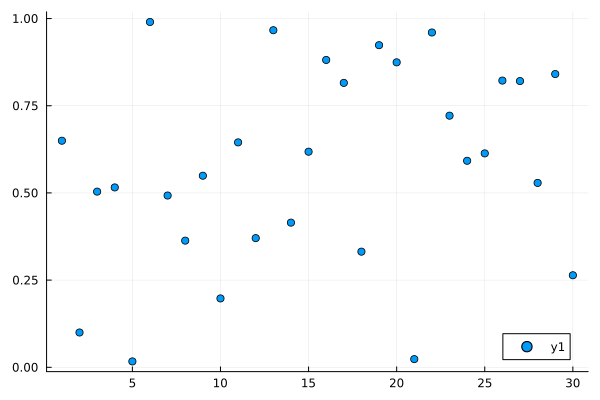

In [45]:
scatter(pitvals_manual)

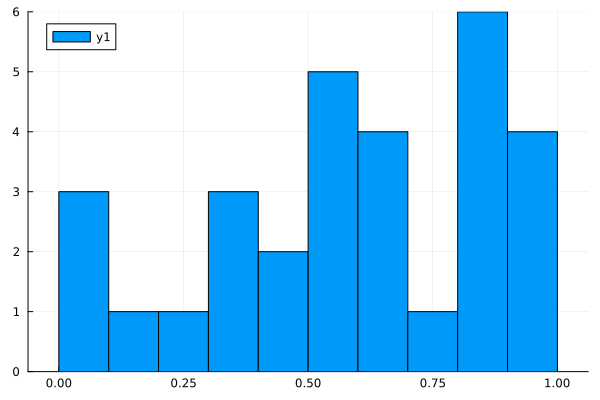

In [44]:
histogram(pitvals_manual, bins=10)

In [11]:
y_pred_array

2000×8×30 Array{Float64, 3}:
[:, :, 1] =
 -10.1818   -11.0377   -10.5989   …   -8.01057  -12.6985   -10.4819
 -11.2925    -9.12294  -10.9325       -9.24779  -10.3826   -10.076
 -11.3934    -9.9912   -10.7854      -11.0391   -11.5392    -9.91022
  -9.15186   -9.29875  -10.4015      -10.403    -10.5679   -11.8839
  -9.41911  -11.7445    -9.74302      -7.56003  -10.4845   -11.0307
  -9.99668   -9.87382   -7.781    …   -9.88694   -9.77463  -10.562
  -9.23335   -9.31192   -8.81793      -9.53515  -11.2048   -10.4202
 -10.002    -11.0475    -8.81079      -9.89486  -11.7926    -8.56123
  -8.9629   -10.7703   -10.17        -10.76     -11.6769    -7.74559
 -11.2327   -11.6712   -12.1231       -9.8742   -10.4041   -10.1628
 -11.905     -8.60823   -7.69922  …   -9.38767   -9.49252   -8.54825
  -9.76017   -8.80803  -12.0719      -10.6687    -9.76031  -10.2263
  -9.89574  -10.3719    -8.55856      -9.81908  -10.959    -11.1
   ⋮                              ⋱    ⋮                   
  -8.09668  -10.

In [12]:
y_1_array = []
for i in 1:8
    y_1_array = append!(y_1_array, y_pred_array[:,i,1])
end

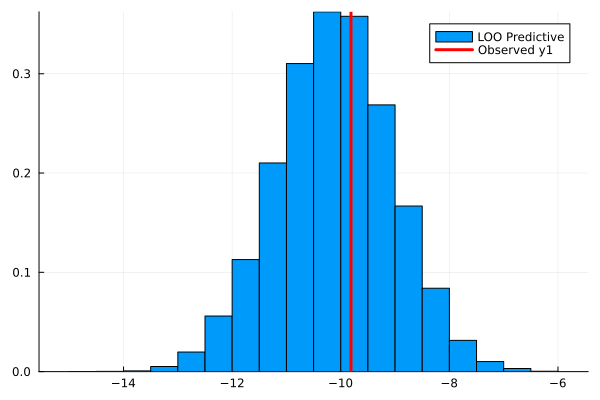

In [13]:
histogram(y_1_array, normalize=:pdf, bins = 20, label="LOO Predictive")
vline!([y[1]], color=:red, linewidth=3, label = "Observed y1")

### Ethan's Manual LOO-PIT

In [14]:
y_pred

Chains MCMC chain (2000×30×8 Array{Float64, 3}):

Iterations        = 1:1:2000
Number of chains  = 8
Samples per chain = 2000
parameters        = y[1], y[2], y[3], y[4], y[5], y[6], y[7], y[8], y[9], y[10], y[11], y[12], y[13], y[14], y[15], y[16], y[17], y[18], y[19], y[20], y[21], y[22], y[23], y[24], y[25], y[26], y[27], y[28], y[29], y[30]
internals         = 

Summary Statistics
  parameters       mean       std      mcse     ess_bulk     ess_tail      rha ⋯
      Symbol    Float64   Float64   Float64      Float64      Float64   Float6 ⋯

        y[1]   -10.1154    1.0680    0.0084   16052.1143   15619.2564    1.000 ⋯
        y[2]    -9.6302    0.9799    0.0079   15316.4400   15281.4769    1.000 ⋯
        y[3]    -9.1219    3.2593    0.0257   16042.2965   15360.2082    1.000 ⋯
        y[4]    -8.6605    1.8395    0.0144   16221.2487   15340.1434    0.999 ⋯
        y[5]    -8.1408    1.1395    0.0091   15751.9522   15859.8987    1.000 ⋯
        y[6]    -7.6571    1.1184    0.0088  

In [15]:
idata = from_mcmcchains(
        chns;
        posterior_predictive = y_pred,
        constant_data=(; x),
        observed_data=(; y),
        dims=(x=[:i], y=[:i], pred=[:i]),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > sample_stats
  > observed_data
  > constant_data

In [16]:
function inv_diag_cholesky(F::Cholesky)
    if F.uplo == 'U'
        U = inv(UpperTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachrow(U))
    else
        L = inv(LowerTriangular(F.factors))
        return map(Base.Fix1(sum, abs2), eachcol(L))
    end
end

function pointwise_normal_loglikelihood!(
    log_like::AbstractArray,
    cov::AbstractMatrix,
    mean::AbstractVector,
    obs::AbstractVector,
)
    F = cholesky(cov)
    c = inv_diag_cholesky(F)
    g = F \ (obs - mean)
    @. log_like = (log(c) -g^2 / c - log(2π)) ./ 2
end

function pointwise_normal_loglikelihood(
    obs::AbstractVector, mean::AbstractArray, cov::AbstractArray
)
    num_sample_dims = ndims(mean) - 1
    @assert num_sample_dims ∈ (1, 2)
    @assert ndims(cov) == num_sample_dims + 2
    @assert length(obs) == 
        size(mean, num_sample_dims + 1) ==
        size(cov, num_sample_dims + 1) == 
        size(cov, num_sample_dims +2)

    cov_dims = ntuple(i -> i + num_sample_dims, 2)
    sample_dims = ntuple(identity, num_sample_dims)

    cov_axes = map(i -> axes(cov, i), cov_dims)
    sample_axes = map(i -> axes(cov, i), sample_dims)
    out_axes = (sample_axes..., cov_axes[1])

    log_like = similar(obs, Base.promote_eltype(obs, mean, cov), out_axes)
    foreach(
        pointwise_normal_loglikelihood!,
        eachslice(log_like; dims=sample_dims),
        eachslice(cov; dims=sample_dims),
        eachslice(mean; dims=sample_dims),
        Iterators.repeated(obs),
    )

    return log_like
end

pointwise_normal_loglikelihood (generic function with 1 method)

In [17]:
I_n = Matrix{Float64}(I, n, n)
Id = repeat(reshape(I_n, 1, 1, n, n), 2000, 1, 1, 1);

In [18]:
log_like = pointwise_normal_loglikelihood(
    idata.observed_data.y,
    µ_array,
    Id,
)

2000×1×30 Array{Float64, 3}:
[:, :, 1] =
 -0.9350173520314564
 -0.9993277166103288
 -1.117260895468267
 -1.0642225072703788
 -1.0963314493790393
 -0.9246490176300072
 -0.9999758726808696
 -0.9360948761824285
 -0.9447089241175762
 -0.9476581980489767
 -0.9284064680767724
 -0.9473123568534934
 -0.9473123568534934
  ⋮
 -0.9220504796445945
 -0.9513161828469676
 -0.9257923227758301
 -0.9974570200510309
 -1.0363564817626043
 -1.028588185354429
 -1.028588185354429
 -0.9221504742868959
 -0.9575989688756396
 -0.9561128691569574
 -0.9521352569596393
 -0.9521352569596393

[:, :, 2] =
 -1.8444660629746847
 -1.5825791886495264
 -1.3515667694662943
 -1.4330434048800789
 -1.3827341199512422
 -1.9403846618027583
 -1.5754546995920566
 -1.838097705628635
 -1.7785966566440052
 -1.7627675480693772
 -1.8908444617707874
 -1.760714832933766
 -1.760714832933766
  ⋮
 -1.9751725029055724
 -1.7495881273187812
 -1.922513186362042
 -1.5737442515956337
 -1.481298987553817
 -1.5022004259742032
 -1.5022004259742032
 

In [19]:
idata = merge(
    idata,
    InferenceData(; log_likelihood = namedtuple_to_dataset((; y = log_like))),
)

InferenceData with groups:
  > posterior
  > posterior_predictive
  > log_likelihood
  > sample_stats
  > observed_data
  > constant_data

In [20]:
psis_result = Vector{PSISResult{Float64, Vector{Float64}, Int64, Int64, PSIS.GeneralizedPareto{Float64}}}(undef, n);

In [21]:
for i in 1:n
    psis_result[i] = psis(Array(idata.log_likelihood[:,1,i][:y]))
end

In [22]:
draws = Vector{Vector{Float64}}(undef, 2000*8)

for i in 1:2000
    for j in 1:8
        new_µ = vec(µ_array[i,j,:])
        dist = MvNormal(new_µ, I)
        draws[(i-1)*8 + j] = rand(dist)
    end
end

In [30]:
comparison_values = Array{Float64}(undef, n, 2000)

for j in 1:2000
    draw = draws[j]
    data = y

    for i in 1:n
        if draw[i] < data[i]
            comparison_values[i,j] = 1
        else
            comparison_values[i,j] = 0
        end
    end
end

In [31]:
PIT_Values = Vector{Float64}(undef, n)
for i in 1:n
    sum = 0
    for j in 1:2000
        sum += comparison_values[i,j] * psis_result[i].weights[j]
    end

    PIT_Values[i] = sum
end

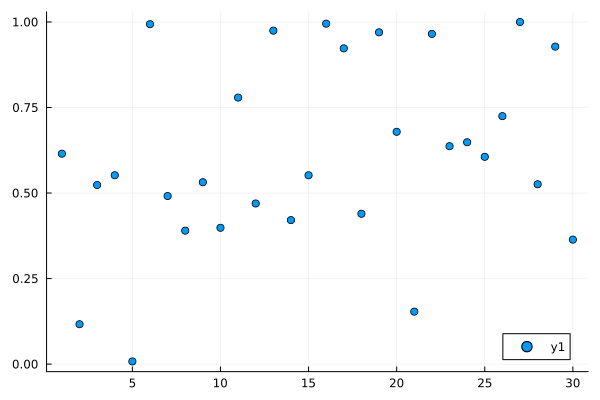

In [32]:
scatter(PIT_Values)

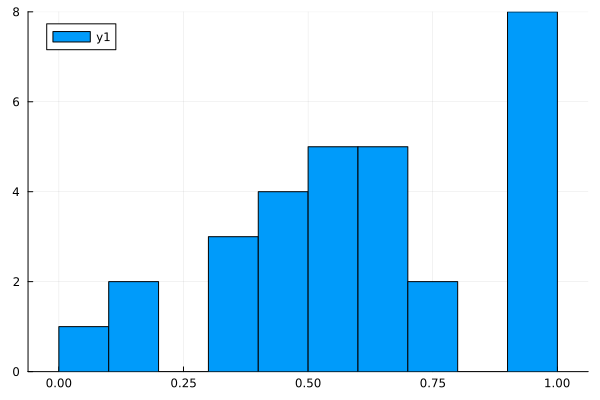

In [33]:
histogram(PIT_Values, bins = 10)

### Comparison of Manual Approaches

In [34]:
println("Marco Manual LOO-PIT (first 5): ", round.(pitvals_manual[1:5], digits=4))
println("Ethan Manual LOO-PIT (first 5): ", round.(PIT_Values[1:5], digits=4))

Marco Manual LOO-PIT (first 5): [0.6497, 0.0998, 0.5037, 0.5158, 0.0168]
Ethan Manual LOO-PIT (first 5): [0.615, 0.1166, 0.5235, 0.552, 0.0078]


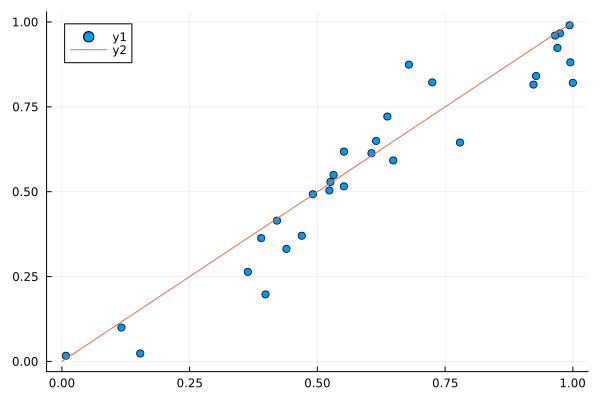

In [41]:
scatter(PIT_Values, pitvals_manual)
plot!([0.0, 0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],[0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])

In [29]:
using HypothesisTests

# Perform the KS test for the Monte Carlo version
ks_test_marco = ExactOneSampleKSTest(pitvals_manual, Uniform(0, 1))

# Perform the KS test for the Exact Analytic version
ks_test_ethan = ExactOneSampleKSTest(PIT_Values, Uniform(0, 1))

println("Marco LOO-PIT KS test p-value:    ", pvalue(ks_test_marco))
println("Ethan LOO-PIT KS test p-value: ", pvalue(ks_test_ethan))

[ Info: Precompiling HypothesisTests [09f84164-cd44-5f33-b23f-e6b0d136a0d5] (cache misses: wrong dep version loaded (2))


Marco LOO-PIT KS test p-value:    0.18965801087934164
Ethan LOO-PIT KS test p-value: 0.02475745105526006
